# Heart Disease Classification — Exploratory Data Analysis

## Objective
Understand the structure, distributions, and relationships in the Cleveland 
Heart Disease dataset to inform cleaning and feature engineering decisions.

## Inputs
- `data/raw/heart.csv`
- Cleveland Heart Disease dataset from UCI — 303 patients, 14 columns
- Column descriptions: 
    - age (in years), 
    - sex (1 = male, 0 = female)
    - cp (chest pain type: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic)
    - trestbps (resting blood pressure mmHg)
    - chol (serum cholesterol mg/dl)
    - fbs (fasting blood sugar > 120 mg/dl, 1 = true, 0 = false)
    - restecg (resting ECG results: 0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria)
    - thalach (maximum heart rate achieved)
    - exang (exercise induced angina, 1 = yes, 0 = no)
    - oldpeak (ST depression induced by exercise)
    - slope (slope of peak exercise ST segment: 1 = upsloping; 2 = flat; 3 = downsloping)
    - ca (number of major vessels 0–3)
    - thal (thalassemia: 3 = normal; 6 = fixed defect; 7 = reversable defect)
    - target (0 = no disease, 1-4 = disease sevarity)
## Output
- Key observations documented below to guide Data cleaning + feature engineering

## Key Questions
1. What does the class distribution look like?
2. Which features show the strongest separation between classes?
3. Are there missing values or anomalies to address?
4. What relationships exist between features?

## 1.1 Setup & Imports

Importing core libraries for data manipulation, visualization, and analysis. Path constants and random state are defined here to ensure reproducibility and consistent file references throughout the notebook. Warning suppression keeps the output clean.

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
RAW_DATA_PATH = '../data/raw/heart.csv'
PROCESSED_DATA_PATH = '../data/processed/heart_cleaned.csv'

## 1.2 Load Data

Loading the raw Cleveland Heart Disease dataset from `data/raw/heart.csv`. Column names are applied manually since the raw UCI file has no header row. Sanity checks confirm 303 rows and 14 columns as expected.

In [ ]:
columns = ['age','sex','cp', 'trestbps','chol', 'fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(RAW_DATA_PATH, names = columns, header = None)
print(df.shape)
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1.3 Sanity Checks

For the sanity check I will first check to make sure the data types of all variables are numerical. 

In [ ]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object

After running `df.dtypes`, every column except `ca` and `thal` are numerical. Since `ca` and `thal` are object dtype, I suspect they contain missing values. To confirm, I check for `?` characters explicitly since the UCI documentation specifies missing values are 
encoded as `?`.

In [29]:
df.isin(['?']).sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

The results confirm that `ca` and `thal` have missing values, with `ca` having 4 and `thal` having 2. These will be addressed in `02_feature_engineering.ipynb`. Next I investigate the dataset for any variables with values that could signal outliers or data 
entry errors.

In [28]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


Some variables that stand out are `chol` with max = 564 but 75th percentile = 275, `thalach` with max = 202 but 75th percentile = 166, and `oldpeak` with max = 6.2 but 75th percentile = 1.6. These gaps suggest potential outliers. The `thalach` max of 202 is also notable since the maximum human heart rate is approximately 220 minus age — with the minimum age being 29, this value is at the very edge of physiological plausibility.

## 1.4 Target Distribution

In [5]:
df['target'].value_counts()
df['target'].value_counts(normalize = True)

target
0    0.541254
1    0.181518
2    0.118812
3    0.115512
4    0.042904
Name: proportion, dtype: float64

The distribution of the target variable across its raw `0-4` encoding is: `0`: 54.1%, `1`: 18.2%, `2`: 11.9%, `3`: 11.6%, `4`: 4.3%. Since I will binarize the target in feature engineering, collapsing categories `1-4` into a single positive class gives a roughly 54/46 split, making accuracy a more meaningful metric than it would be for a heavily imbalanced dataset. However, since this is a medical classification problem, accuracy alone is not sufficient — a false negative (predicting no disease when disease is present) is far more costly than a false positive. I will therefore report accuracy, precision, recall, F1, and AUC-ROC.

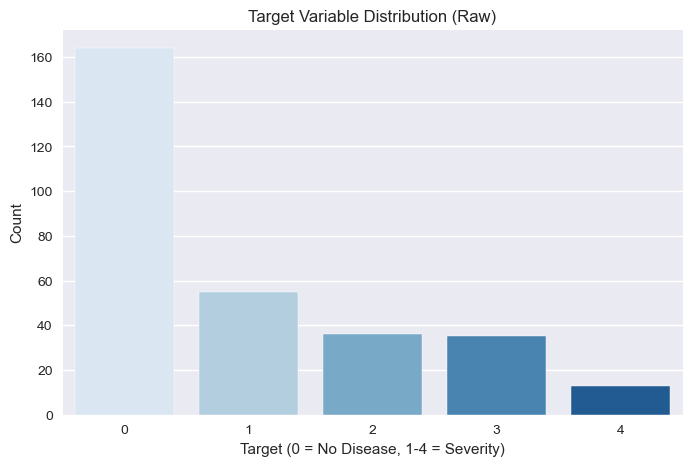

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='Blues')
plt.title('Target Variable Distribution (Raw)')
plt.xlabel('Target (0 = No Disease, 1-4 = Severity)')
plt.ylabel('Count')
plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

## 1.5 Univariate Analysis

### Continuous Features: 
    'age','trestbps','chol','thalach','oldpeak'

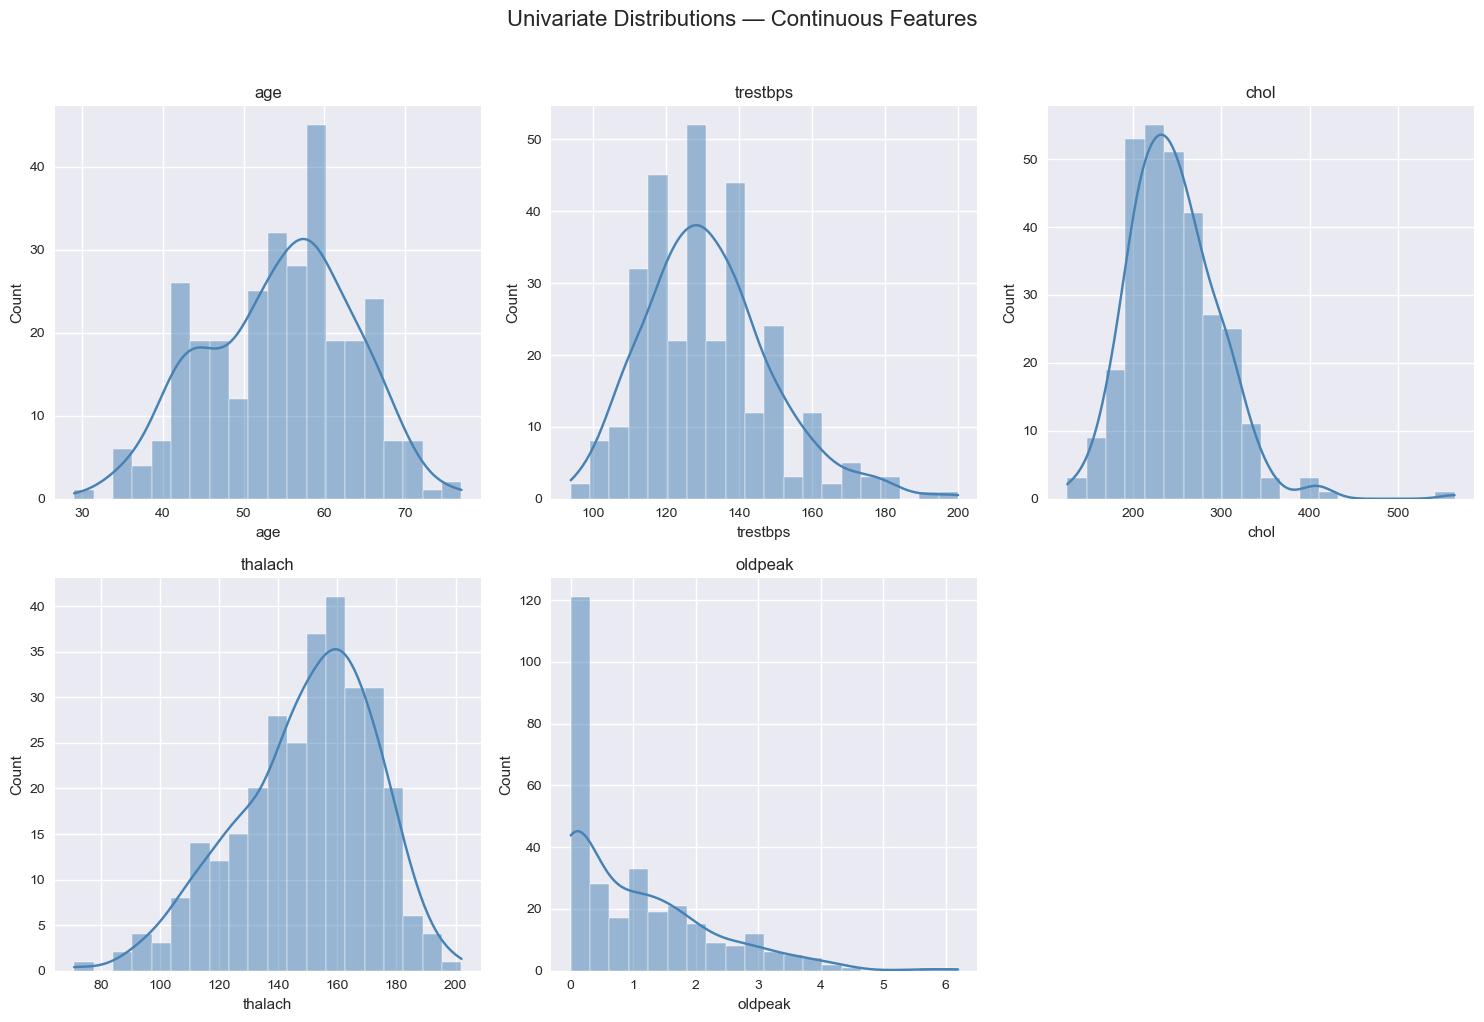

In [11]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(df[feature], bins=20, kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()

To visualize the shape of each continuous feature's distribution I plotted a histogram overlaid with a KDE curve. Since histograms are sensitive to bin size, the KDE gives a cleaner picture of the underlying distribution shape regardless of binning choices.

**Age:** Roughly normally distributed with slight irregularity, centered around 54-58 with most patients falling between 40-70. No outliers are visible. The wide spread signals high variation across the patient cohort. The age range of roughly 30-77 confirms this 
is a middle-aged to elderly sample, which is expected for a heart disease study.

**Trestbps:** Right skewed with a peak around 130 mmHg. The minimum around 90-100 is physiologically plausible. The right tail extends to 200 mmHg which is clinically extreme and will be investigated further in feature engineering.

**Chol:** Heavily right skewed with the bulk of values clustering around 200-300 but with a long right tail and an extreme value past 500. While not physiologically impossible, this is a notable outlier that will be revisited in feature engineering.

**Thalach:** Left skewed with an outlier below 80 but without a very long tail. The spread is wide. Since maximum heart rate decreases naturally with age, lower `thalach` values likely correspond to older patients — suggesting `thalach` and `age` may have an interaction worth exploring in feature engineering.

**Oldpeak:** Heavily right skewed with values concentrated near 0. The right tail represents patients with significant ST depression, which is a strong indicator of heart disease, making this a highly informative feature. Given its 0-6 range and heavy concentration at 0, a log transform will likely be needed in feature engineering — however since `log(0)` is undefined, a standard log transform won't work directly and will need special handling.

### Categorical Features: 
`sex`,`cp`,`fbs`,`restecg`,`exang`,`slope`,`ca`,`thal`


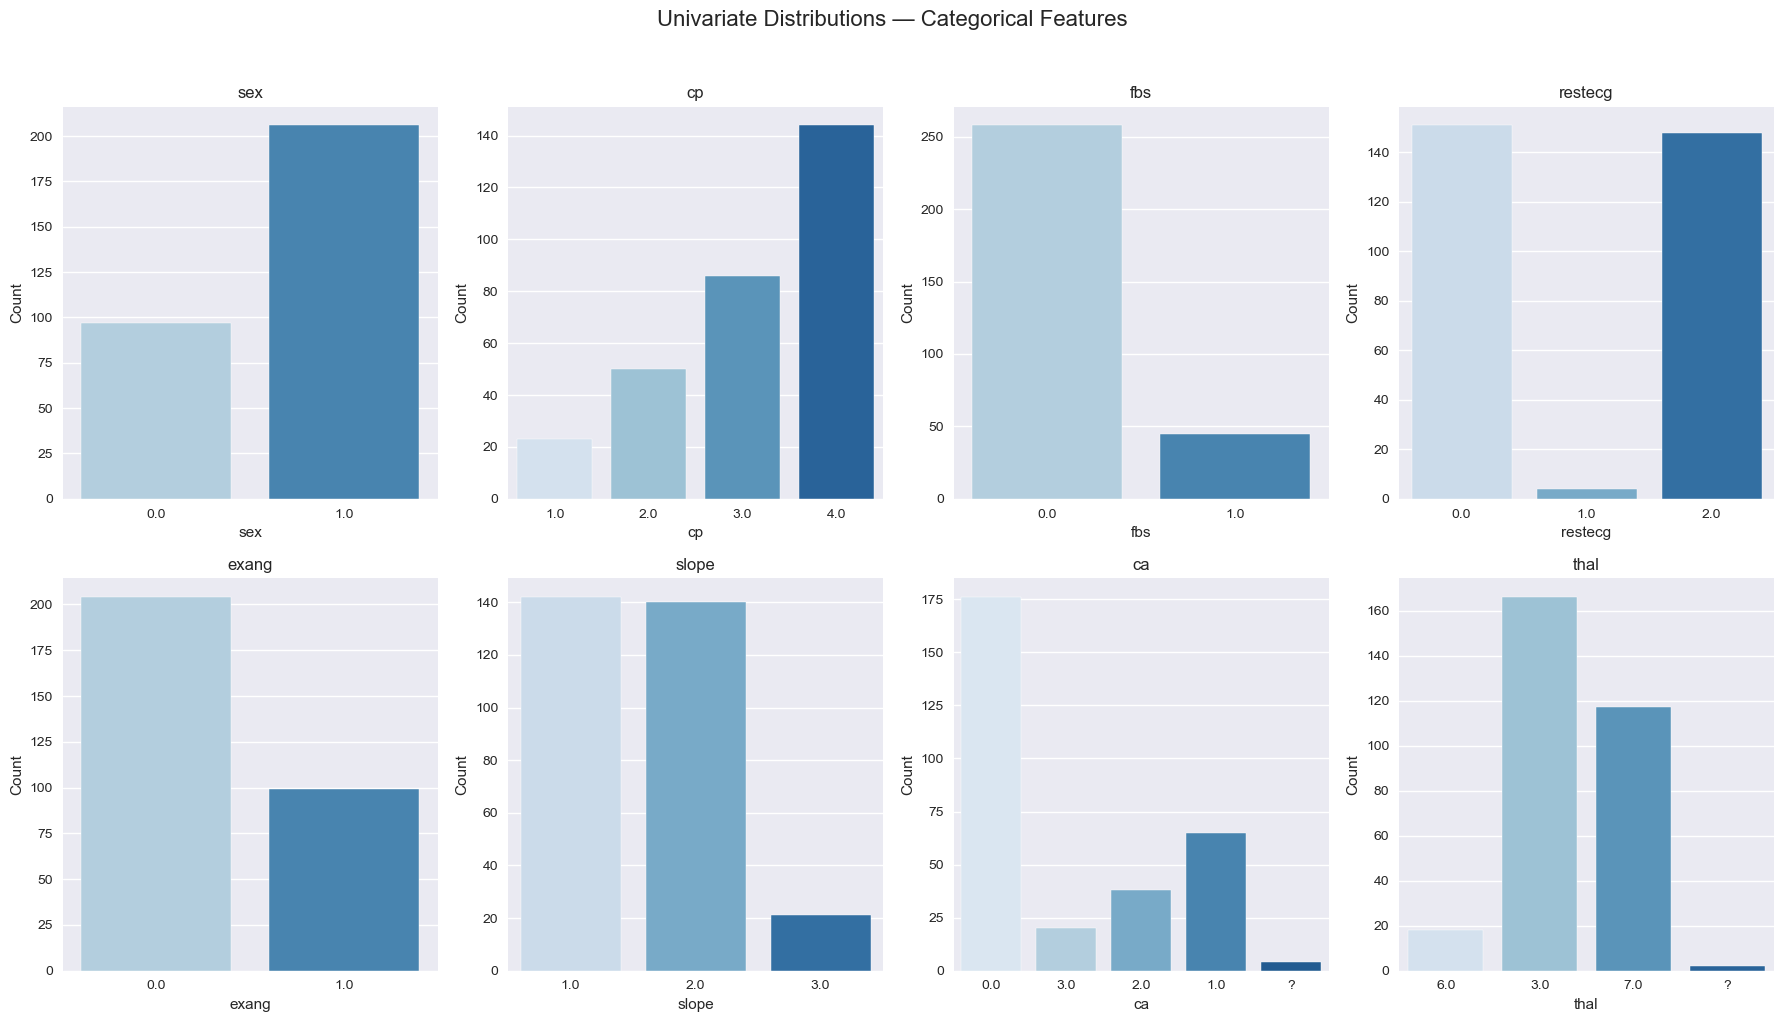

In [12]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, data=df, ax=axes[i], palette='Blues')
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

To visualize the frequency of each discrete category I plotted a countplot for each categorical feature.

**Sex:** The dataset is 68% male and 32% female, making it male-dominated. This imbalance may affect how well the model generalizes across sexes and is worth monitoring.

**Cp:** There is a relatively consistent increase in count from `cp=1` to `cp=4`. The uneven distribution across categories may require grouping in feature engineering, since rare categories give the model fewer examples to learn from and can lead to unstable 
estimates.

**Fbs:** Category `0` overwhelmingly dominates over category `1`, indicating low variance. Whether to retain or drop this feature will be decided after evaluating its relationship with the target in bivariate analysis.

**Restecg:** Categories `0` and `2` are roughly equal and both dominate over category `1`, which is extremely rare at roughly 1% of patients. This may require grouping in feature engineering. Retention decision deferred to bivariate analysis.

**Exang:** No-angina patients outnumber angina patients at roughly a 2:1 ratio. Given that exercise-induced angina is a known symptom of coronary artery disease, this feature is expected to be clinically meaningful.

**Slope:** Categories `1` and `2` are roughly equal and both dominate over category `3`. Will consider grouping in feature engineering given the low count at category `3`.

**Ca:** Category `0` overwhelmingly dominates, but despite this `ca` is one of the strongest known predictors of coronary artery disease and dropping it based on distribution alone would be a mistake. The `?` bars visible in the plot correspond to the missing 
values identified earlier in section 1.3.

**Thal:** Categories `3` and `7` dominate over category `6`, with category `3` being the most common. May consider grouping in feature engineering. The `?` category again reflects the known missing values in this column.

### Summary
The most notable data quality flags from univariate analysis are potential outliers in `trestbps` and `chol`, heavy skew in `oldpeak` requiring special transformation handling, and missing values in `ca` and `thal` visualized as `?` categories. Features with low 
variance (`fbs`) or rare categories (`restecg` category `1`, `slope` category `3`) may require grouping or dropping — decisions deferred to bivariate analysis. All feature retention decisions will be made after evaluating relationships with the target variable.

## 1.6 Bivariate Analysis

### Continuous Features:

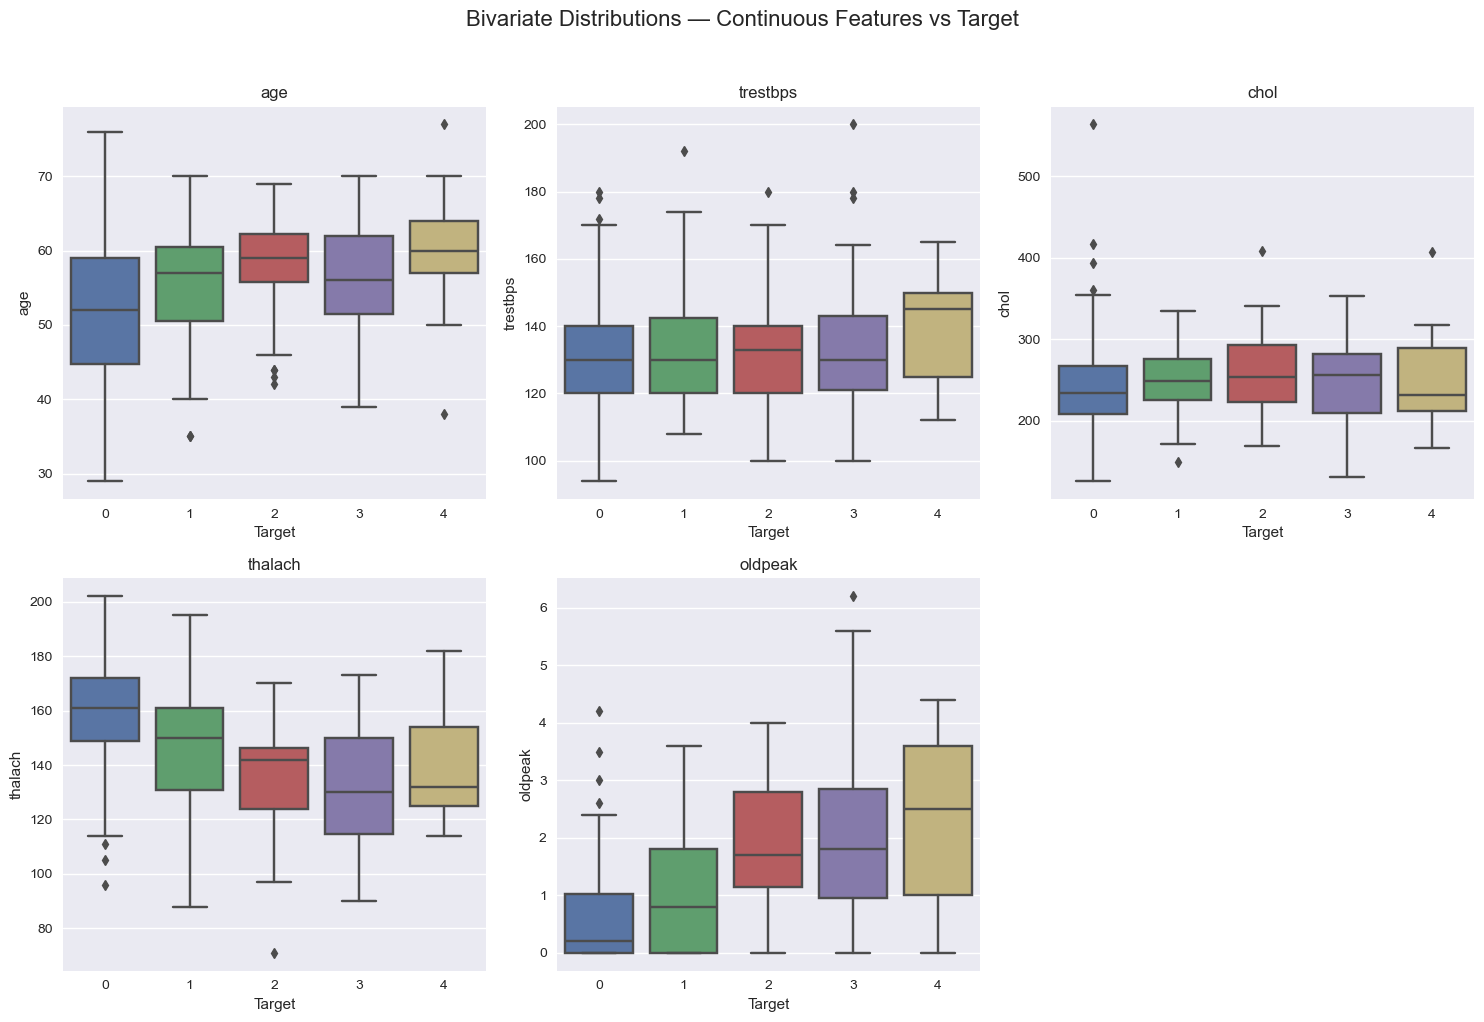

In [4]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(x='target', y=feature, data=df, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(feature)

axes[-1].set_visible(False)

fig.suptitle('Bivariate Distributions — Continuous Features vs Target', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/bivariate_continuous.png', bbox_inches='tight')
plt.show()

**Age:** The median increases steadily from target `0` to `4`, except at category `3` where it dips back to around the same level as category `1`. There is substantial overlap across all categories, meaning age alone is a weak-to-moderate predictor despite the 
overall trend.

**Trestbps:** The median lines are roughly equal from `0` to `4` with a slight increase at category `4`. The large overlap across categories makes this a weak predictor. This is surprising given `trestbps`'s clinical relevance, but in this dataset specifically it 
doesn't discriminate well between classes.

**Chol:** The median is roughly equal across all target categories with large overlap throughout. Despite cholesterol's common association with cardiovascular risk, it shows almost no discriminating power in this dataset — a notable and counterintuitive finding.

**Thalach:** There is a steady decrease in median from category `0` to `3` with a slight increase at category `4`. There is relatively little overlap comparing category `0` to categories `3` and `4`. As disease severity increases, maximum achievable heart rate 
decreases, consistent with reduced cardiac function. This makes `thalach` a very strong predictor.

**Oldpeak:** There is a steady increase in median from category `0` to `4`. Categories `2-4` overlap heavily with each other but show clear separation from category `0`. This makes `oldpeak` a strong predictor for separating disease presence from no disease.

### Categorical Features:

In [6]:
df['target'] = df['target'].astype(str) #since it wont work on non-string types

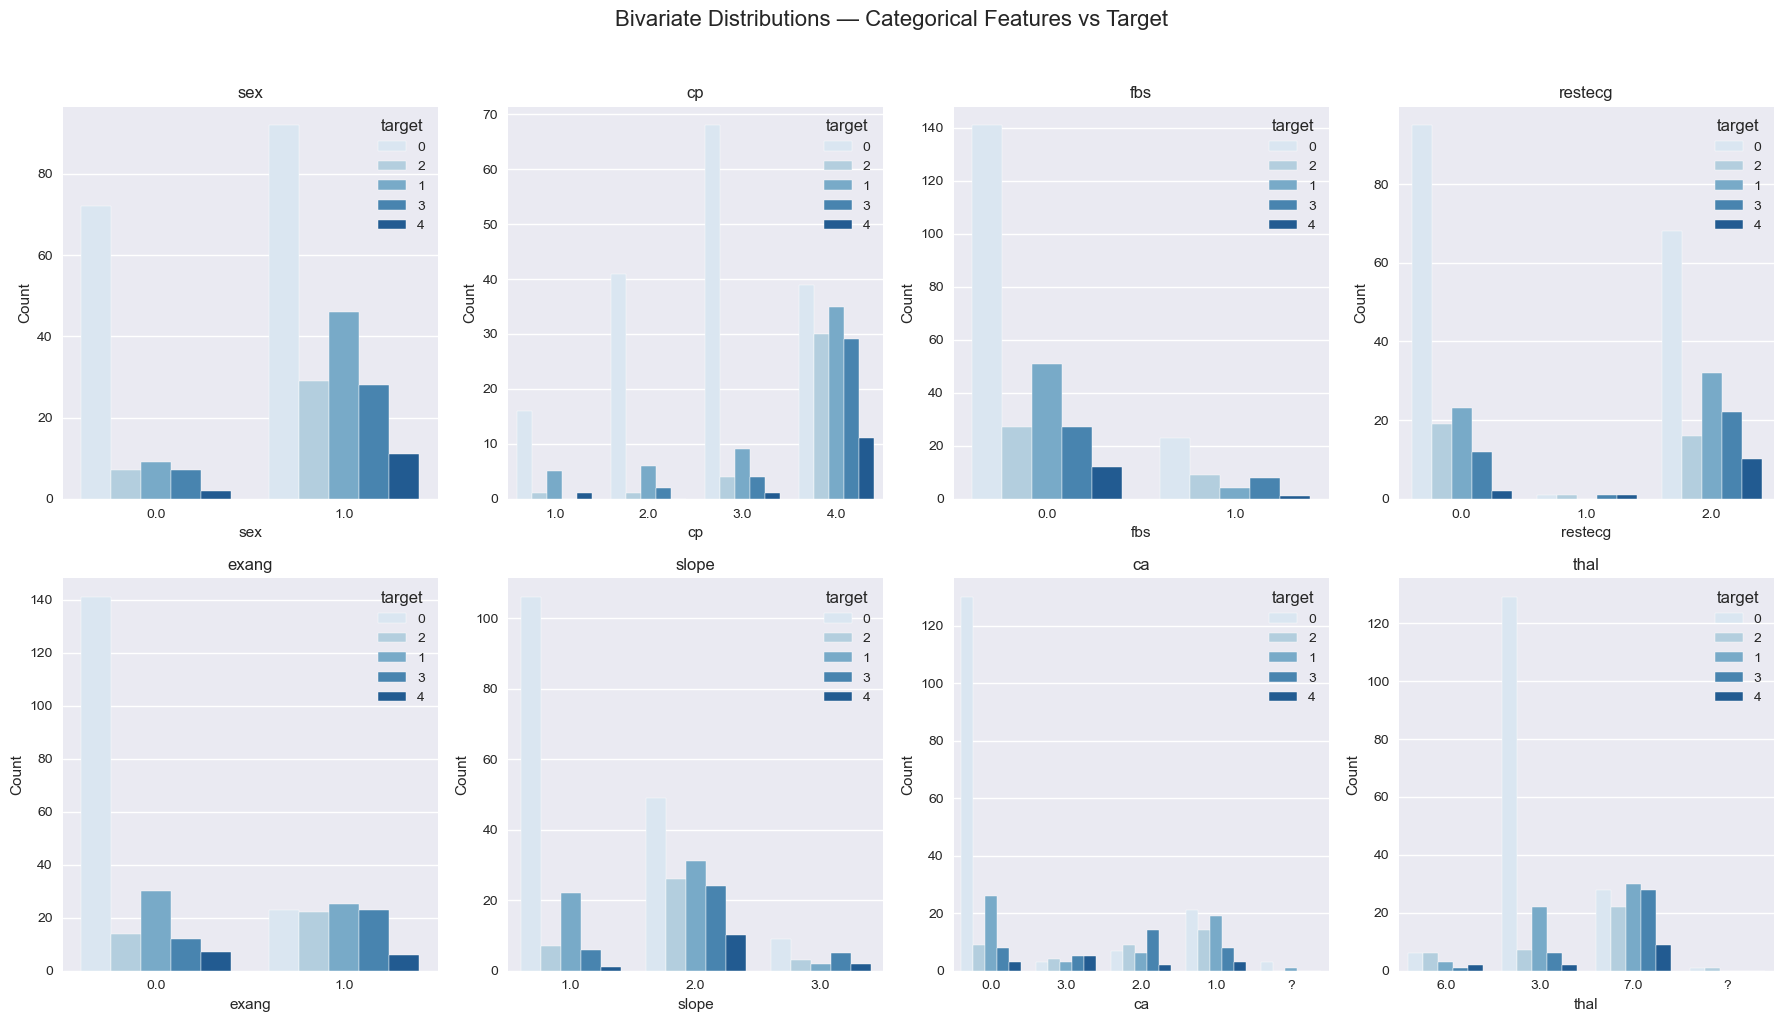

In [7]:
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='target', data=df, ax=axes[i], palette='Blues')
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

fig.suptitle('Bivariate Distributions — Categorical Features vs Target', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/bivariate_categorical.png', bbox_inches='tight')
plt.show()

**Sex:** Among females the majority fall in target `0`, while among males disease cases are much more common proportionally. This makes `sex` a meaningful predictor, though the dataset's male-heavy composition introduces potential for the model to generalize poorly across sexes.

**Cp:** Category `4` has the highest proportion of disease cases, roughly equal to its no-disease count. From `cp=1` to `cp=3` there is a steady increase in disease cases. `Cp` is a very strong predictor since the type of chest pain experienced is highly associated 
with disease presence.

**Fbs:** Target `0` dominates within both `fbs` categories, with roughly similar proportions across them. `Fbs` does not discriminate well between classes, confirming the low variance observation from univariate analysis. This is a weak predictor.

**Restecg:** Categories `0` and `2` have similar distributions with target `0` dominating both. Category `1` is too rare (~1% of patients) to draw reliable conclusions from. Overall a weak-to-moderate predictor.

**Exang:** The majority of `exang=0` patients fall in target `0`, while `exang=1` patients are more evenly distributed across disease categories. Given that exercise-induced angina is a direct symptom of coronary artery disease, it makes clinical sense that `exang=1` 
associates more strongly with disease presence, making it a moderate-to-strong predictor.

**Slope:** The largest disease counts are in category `2`, with fewer in category `1` and very few in category `3`. The proportion of disease cases increases from slope category `1` to `3`, suggesting a meaningful relationship with disease severity.

**Ca:** At `ca=0` no-disease dominates, but as `ca` increases from `1` to `3` disease cases proportionally dominate more strongly. The number of blocked vessels has a clear and consistent relationship with disease presence, making `ca` a very strong predictor. Clinically this makes direct sense.

**Thal:** `Thal=7` (reversible defect) is strongly associated with disease cases while `thal=3` (normal) associates more with no disease. `Thal=6` has very few patients. This makes `thal` a strong predictor.

### Summary
The bivariate analysis highlights clear differences in predictive power across features. `Thalach`, `oldpeak`, `cp`, `ca`, and `thal` show the strongest separation between disease and no-disease patients, consistent with their clinical significance. `Age`, `sex`, `exang`, and `slope` show moderate separation. `Trestbps`, `chol`, `fbs`, and `restecg` show little discriminating power despite some clinical relevance — particularly `chol` and `trestbps` which are counterintuitively weak in this dataset.

The consistent overlap between target categories `1-4` across both continuous and categorical features, contrasted with clear separation from category `0`, reinforces the decision to binarize the target variable in feature engineering.

### Feature Ranking Summary
**Strong:** `thalach`, `oldpeak`, `cp`, `ca`, `thal`
**Moderate:** `age`, `sex`, `exang`, `slope`
**Weak:** `trestbps`, `chol`, `fbs`, `restecg`

## 1.7 Correlation Analysis

Now to confirm observations made with bivariant analysis, I perform correlation analysis to confirm or challenge the observations and to check for multicolliniarity. Visualized by a heatmap

### Correlation Heatmap

In [4]:
#temp convert '?' -> NaN
df_corr = df.replace('?', np.nan).apply(pd.to_numeric, errors='coerce')

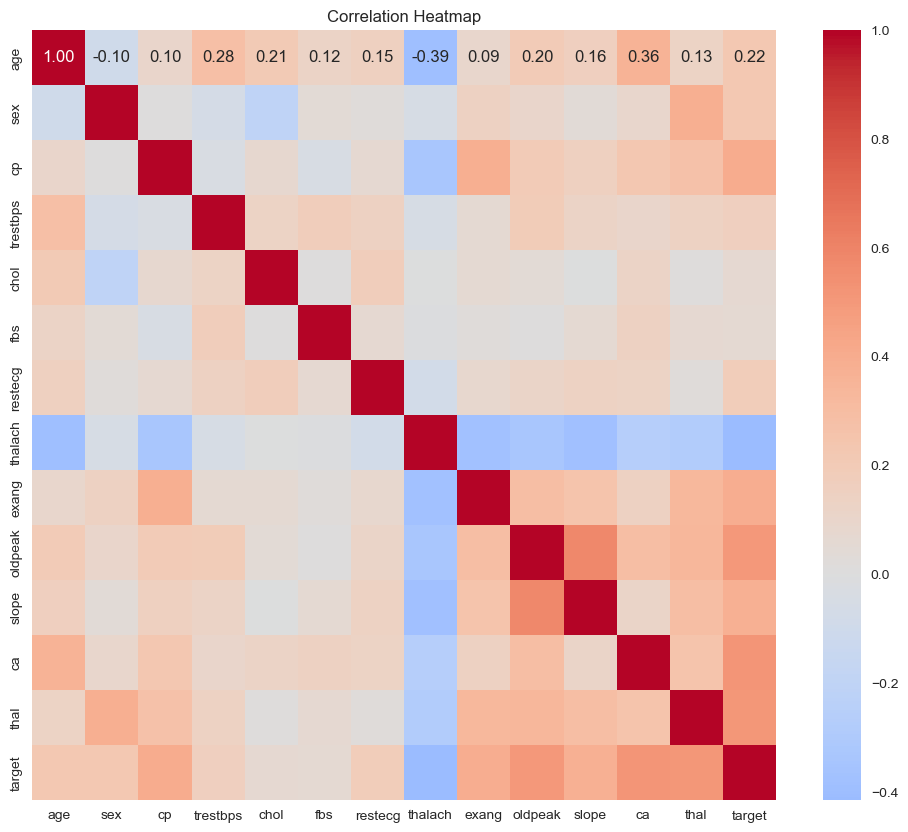

In [7]:
corr_matrix = df_corr.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot = True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Correlation With Target

In [8]:
corr_matrix['target'].sort_values()

thalach    -0.415040
fbs         0.059186
chol        0.070909
trestbps    0.157754
restecg     0.183696
age         0.222853
sex         0.224469
slope       0.377957
exang       0.397057
cp          0.407075
oldpeak     0.504092
thal        0.509923
ca          0.518909
target      1.000000
Name: target, dtype: float64

`Ca`, `thal`, and `oldpeak` have the strongest positive correlations with target at roughly 0.5, supporting the strong predictor ranking from bivariate analysis. `Exang` and `cp` follow at around 0.4, also consistent with previous observations.

`Thalach` is the only feature with a meaningful negative correlation at -0.415. This makes sense given what I saw in the boxplots — as disease severity increases, maximum achievable heart rate decreases. They move in opposite directions, which is captured by 
the negative sign. Despite being negative, the absolute value of 0.415 makes `thalach` one of the strongest predictors in the dataset.

`Fbs`, `chol`, `trestbps`, and `restecg` all have correlations near 0, confirming they are weak predictors with little linear relationship with target. Note that `thalach` should not be grouped with weak predictors despite its negative sign — correlation 
strength is determined by absolute value.

### Multicollinearity

No two features show an extremely strong correlation with each other, but a few moderate relationships are worth noting. The most important is `thalach` and `age` at -0.39. As age increases, maximum heart rate decreases, which is a known physiological relationship. This confirms the interaction between `thalach` and `age` flagged in univariate analysis and is worth revisiting in feature engineering. `Thalach` also shows moderate negative correlations with `exang`, `oldpeak`, `slope`, `ca`, and `thal`, which makes clinical sense since all of these are indicators of disease severity. None of these are strong enough to require immediate action but are worth monitoring during modeling.

### Summary
The correlation analysis largely confirms the feature ranking from bivariate analysis. `Ca`, `thal`, `oldpeak`, `cp`, and `exang` are the strongest predictors. `Fbs`, `chol`, `trestbps`, and `restecg` are the weakest. The `thalach`-`age` interaction is the most 
notable multicollinearity finding and will be revisited in feature engineering.

## 1.8 Key Observations

Through EDA the strongest predictors identified were `ca`, `thal`, `oldpeak`, `cp`, and `exang`, supported by both the correlation analysis and the bivariate distributions. These features showed the clearest separation between disease and no-disease patients and are clinically consistent with coronary artery disease.

Several data quality issues were identified that will need to be addressed in feature engineering. `Ca` and `thal` both contain missing values encoded as `?`. Outliers were found in `chol` (value past 500), `trestbps` (value at 200), and `oldpeak` which is 
heavily concentrated near 0 and will require special handling for log transformation. The small sample size of 303 patients also resulted in some categorical values having very few instances, which may affect model stability.

Some findings were counterintuitive. `Chol` and `trestbps` were surprisingly weak predictors despite their common association with cardiovascular risk. `Age` was also weaker than expected, coming in as only a moderate predictor rather than a strong one.

The most important preprocessing decisions motivated by EDA are: binarizing the target variable from `0-4` to `0/1` based on the consistent overlap between categories `1-4` across all features, and grouping some categorical feature categories that have very few 
instances to give the model more stable estimates to learn from.